In [3]:
!pip install matplotlib
!pip install numpy

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/7e/65/07d5f5c7f7c994f12c768708bd2e17a4f01a2b0f44a1c9eccad872433e2e/matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata
  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/53/3e/405b59cfa13021a56bba395a6b3aca8cec012b45bf177b0eaf7a202cde2c/contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Obtaining dependency information for fonttools>=4.22.0 from https://files.pythonhosted.org/packages/47/d4/dbacced

  STAGE 1  |  active_listening  (2 configs)
Saved: gridsearch_neg15dim_12pairs_matched/active_listening/stage1_plot.png


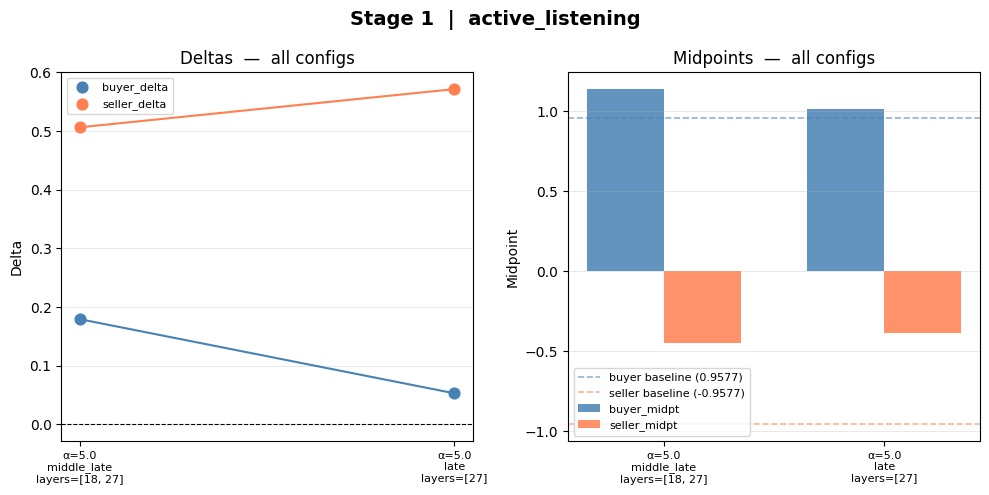


  STAGE 2  |  active_listening  (11 configs)
Saved: gridsearch_neg15dim_12pairs_matched/active_listening/stage2_plot.png


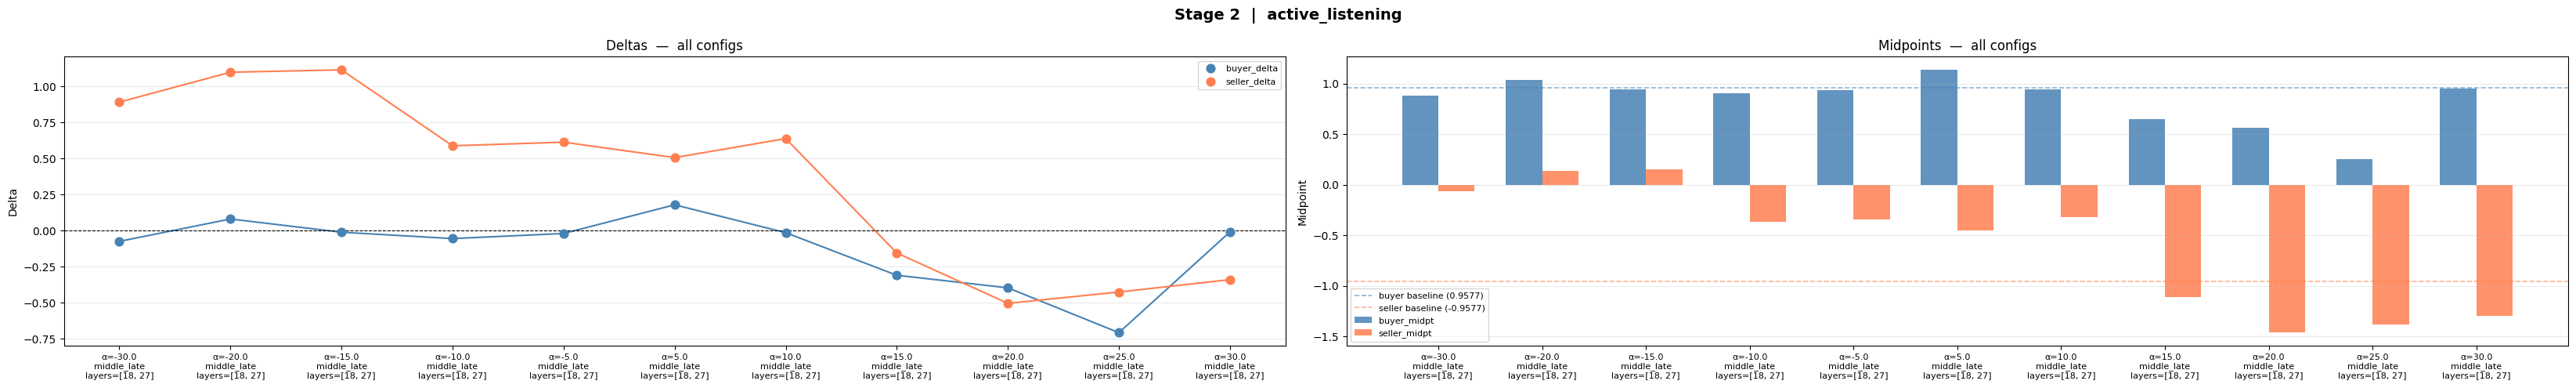

  STAGE 1  |  anchoring  (2 configs)
Saved: gridsearch_neg15dim_12pairs_matched/anchoring/stage1_plot.png


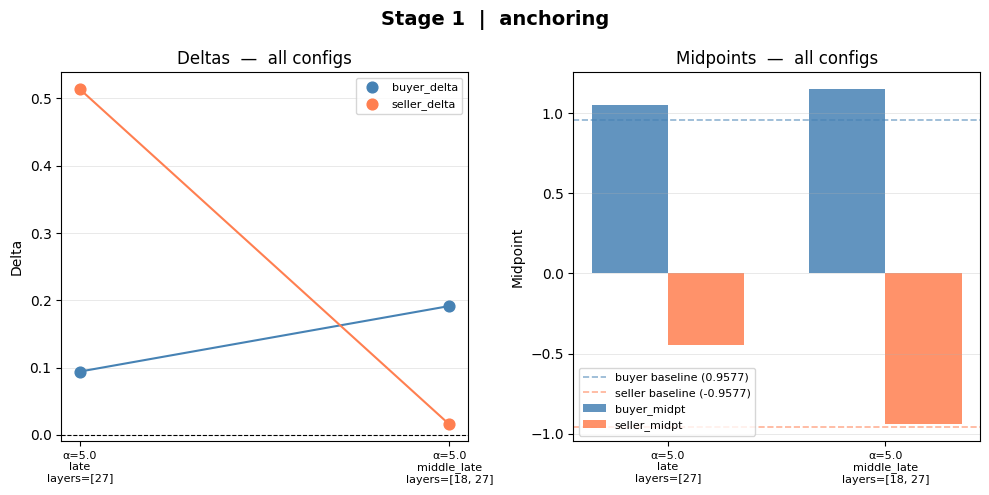


  STAGE 2  |  anchoring  (11 configs)
Saved: gridsearch_neg15dim_12pairs_matched/anchoring/stage2_plot.png


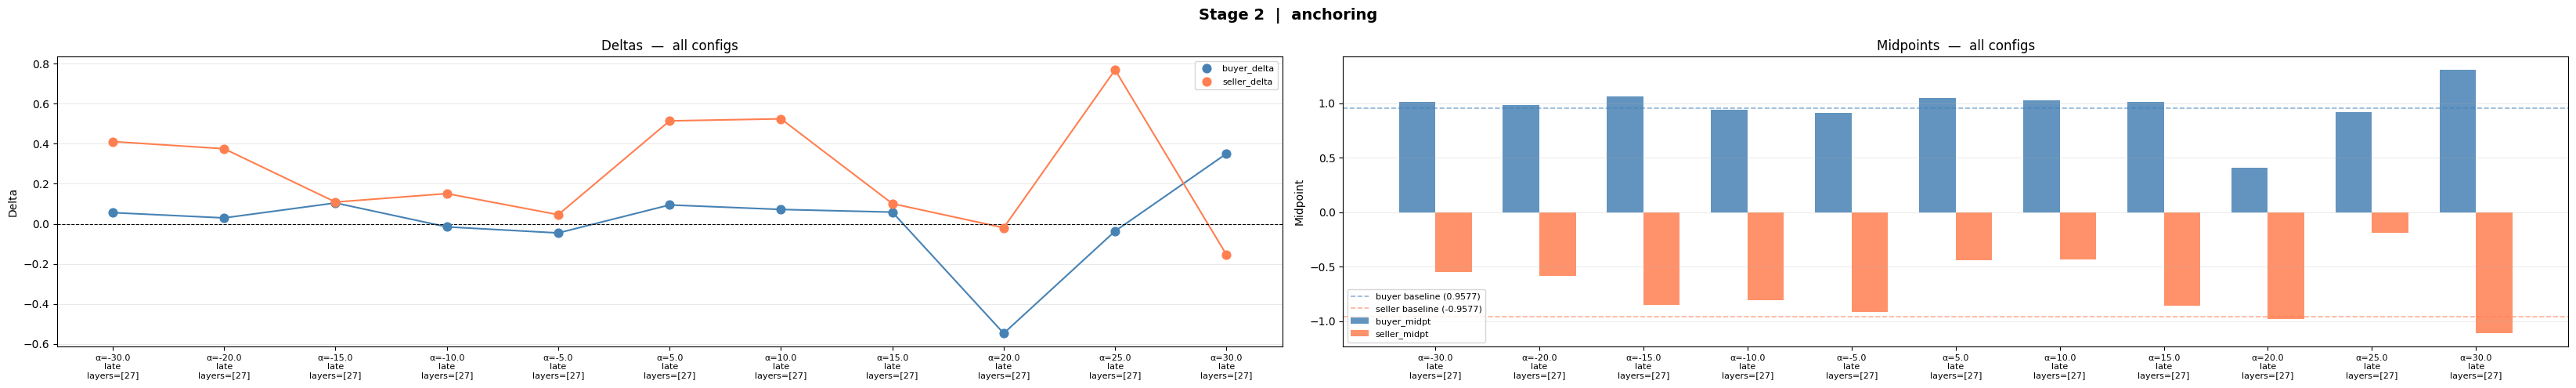

  STAGE 1  |  assertiveness  (2 configs)
Saved: gridsearch_neg15dim_12pairs_matched/assertiveness/stage1_plot.png


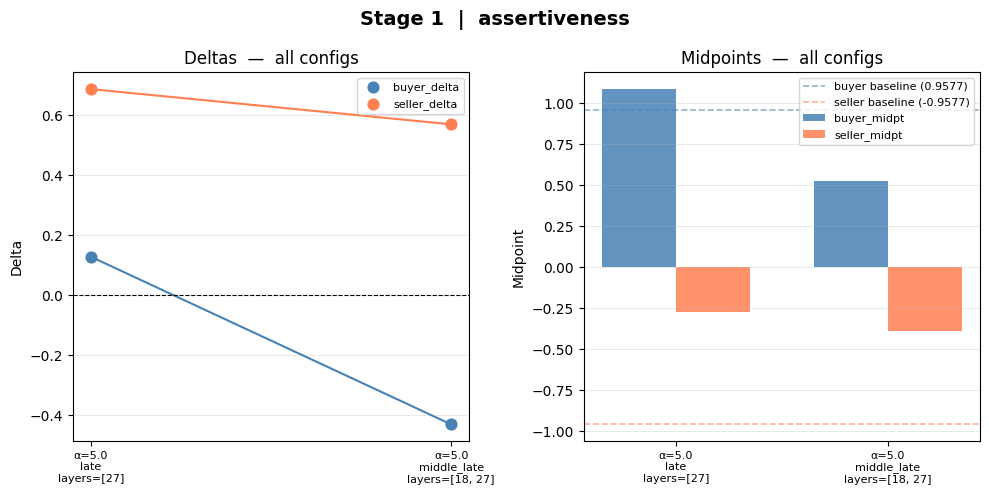


  STAGE 2  |  assertiveness  (11 configs)
Saved: gridsearch_neg15dim_12pairs_matched/assertiveness/stage2_plot.png


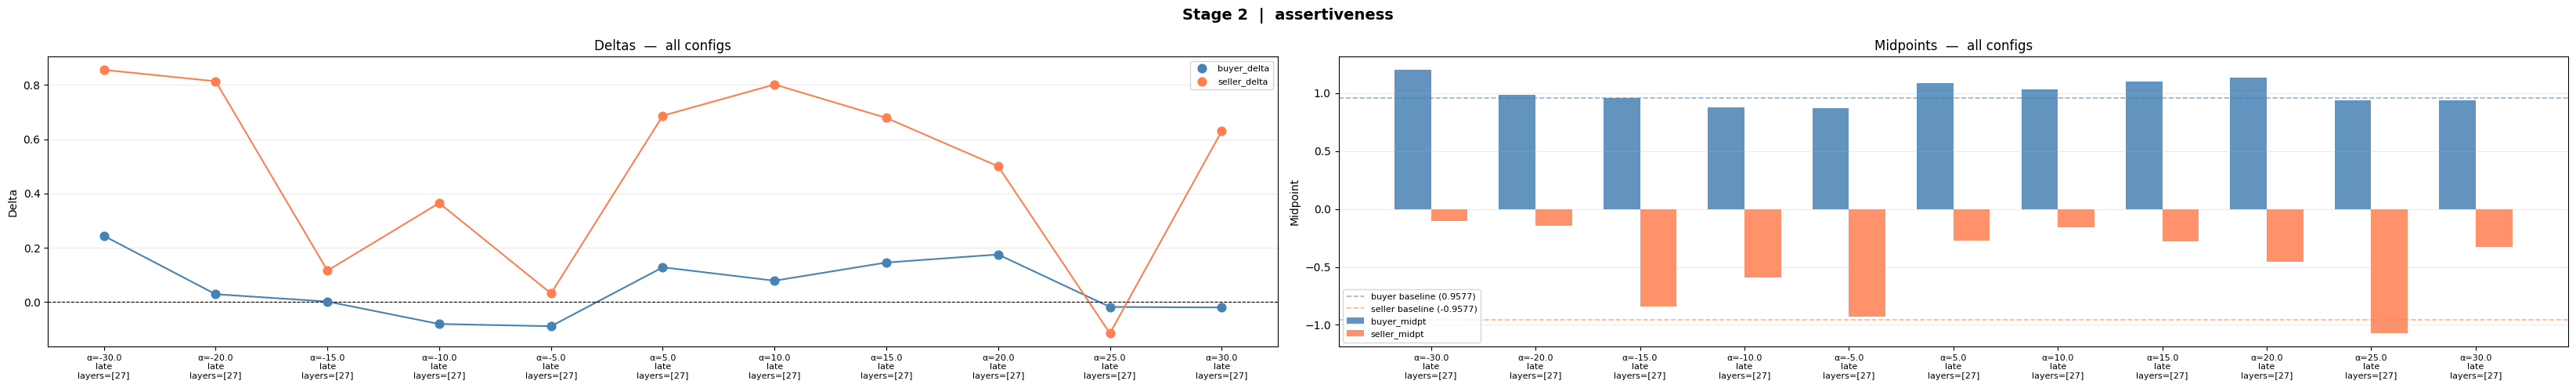

  STAGE 1  |  emotional_regulation  (2 configs)
Saved: gridsearch_neg15dim_12pairs_matched/emotional_regulation/stage1_plot.png


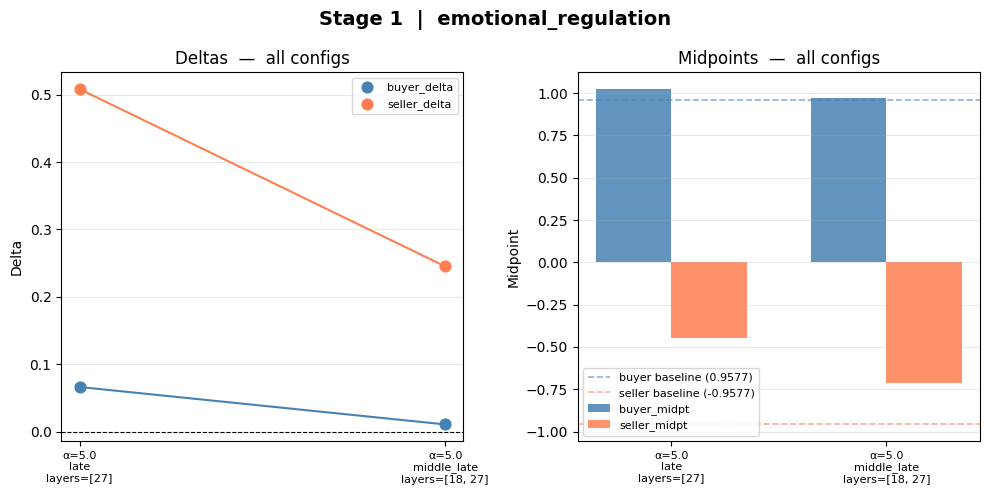


  STAGE 2  |  emotional_regulation  (11 configs)
Saved: gridsearch_neg15dim_12pairs_matched/emotional_regulation/stage2_plot.png


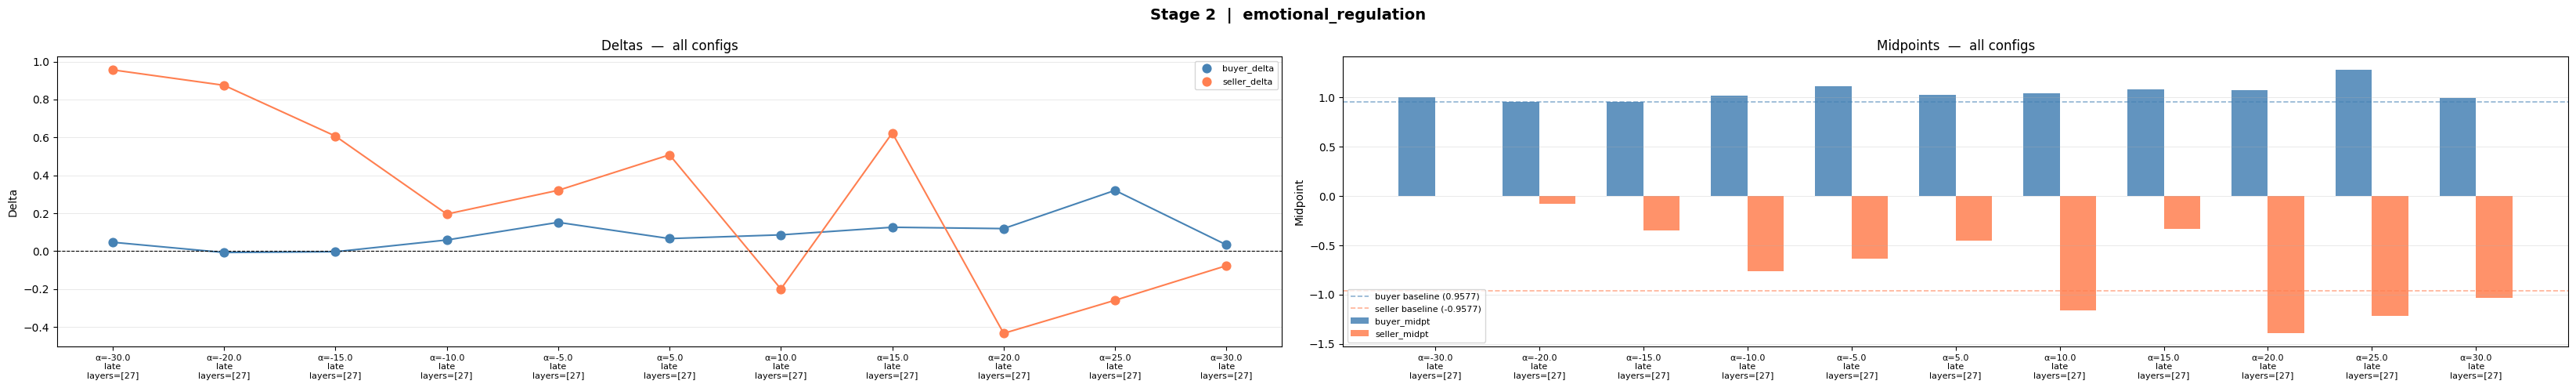

  STAGE 1  |  empathy  (2 configs)
Saved: gridsearch_neg15dim_12pairs_matched/empathy/stage1_plot.png


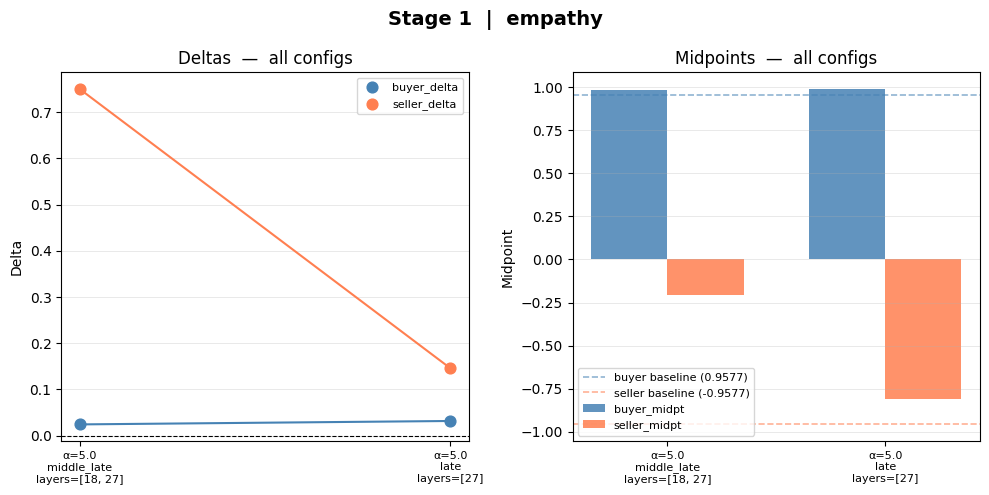


  STAGE 2  |  empathy  (11 configs)
Saved: gridsearch_neg15dim_12pairs_matched/empathy/stage2_plot.png


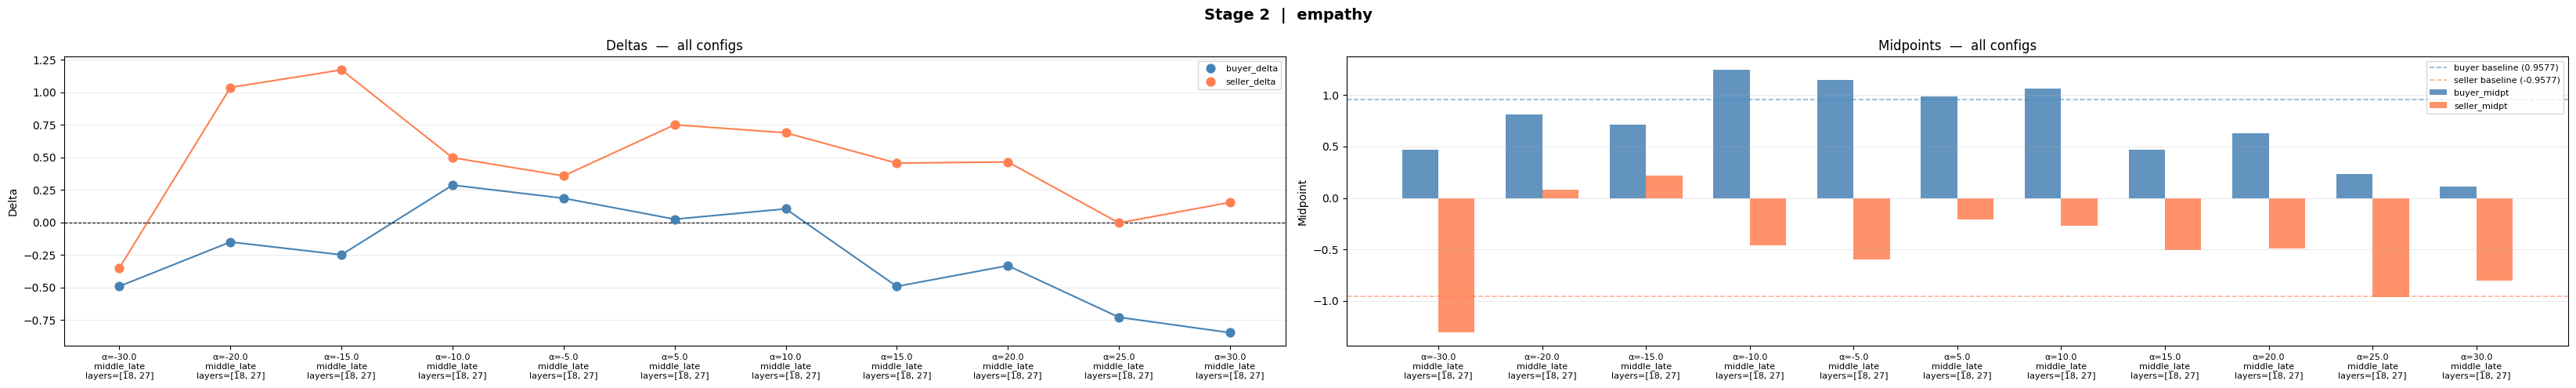

  STAGE 1  |  firmness  (2 configs)
Saved: gridsearch_neg15dim_12pairs_matched/firmness/stage1_plot.png


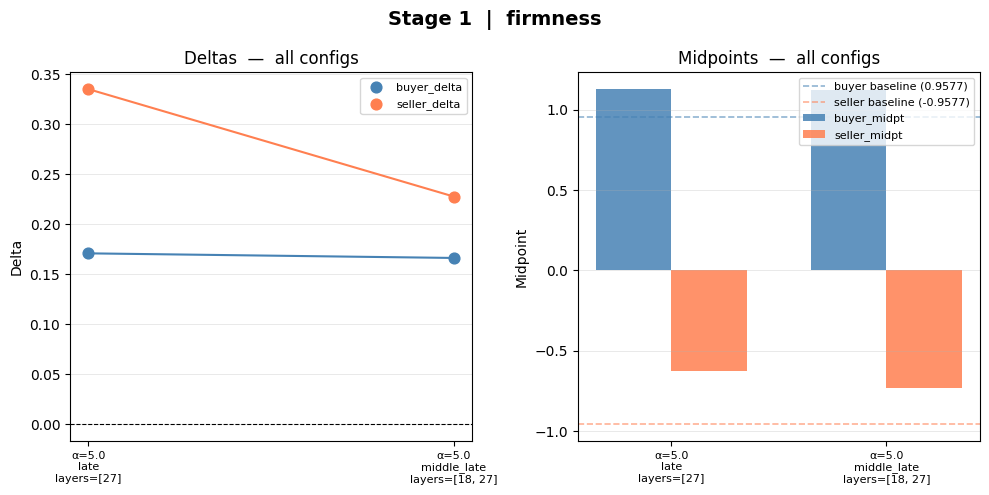


  STAGE 2  |  firmness  (11 configs)
Saved: gridsearch_neg15dim_12pairs_matched/firmness/stage2_plot.png


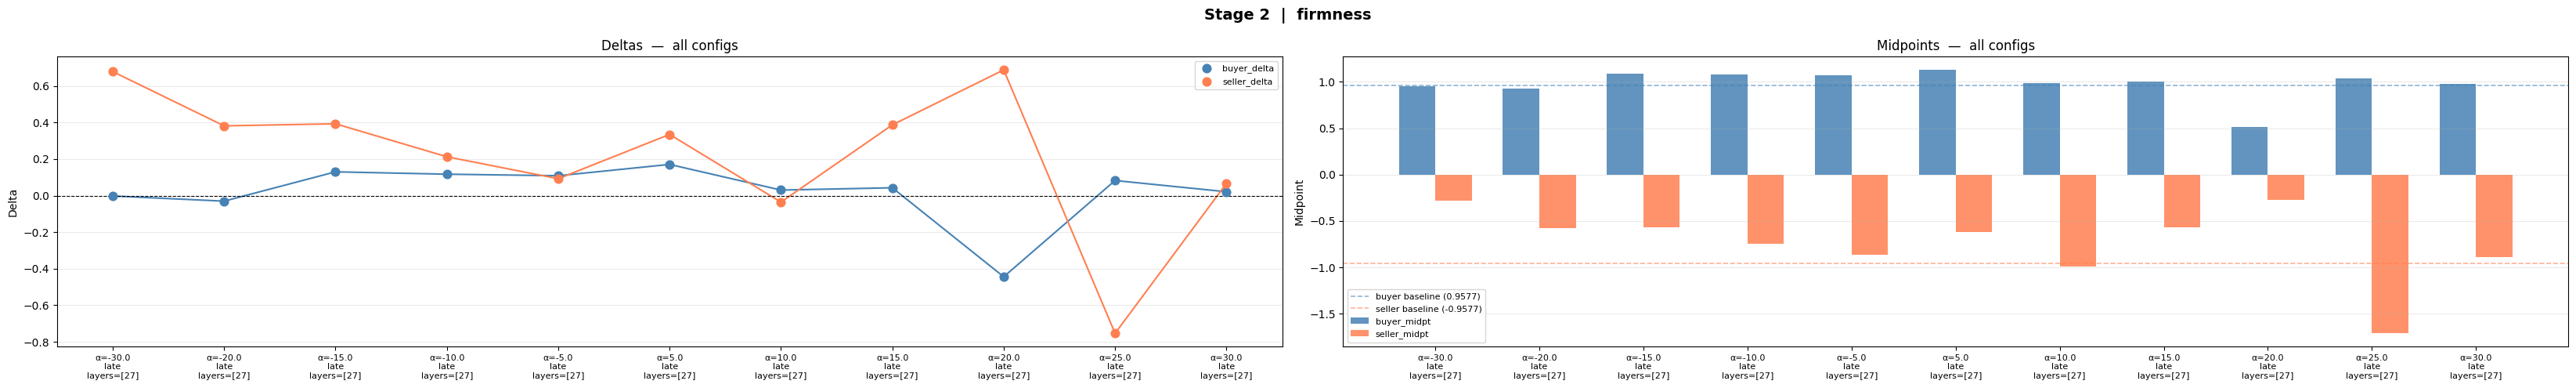

  STAGE 1  |  interest_based_reasoning  (2 configs)
Saved: gridsearch_neg15dim_12pairs_matched/interest_based_reasoning/stage1_plot.png


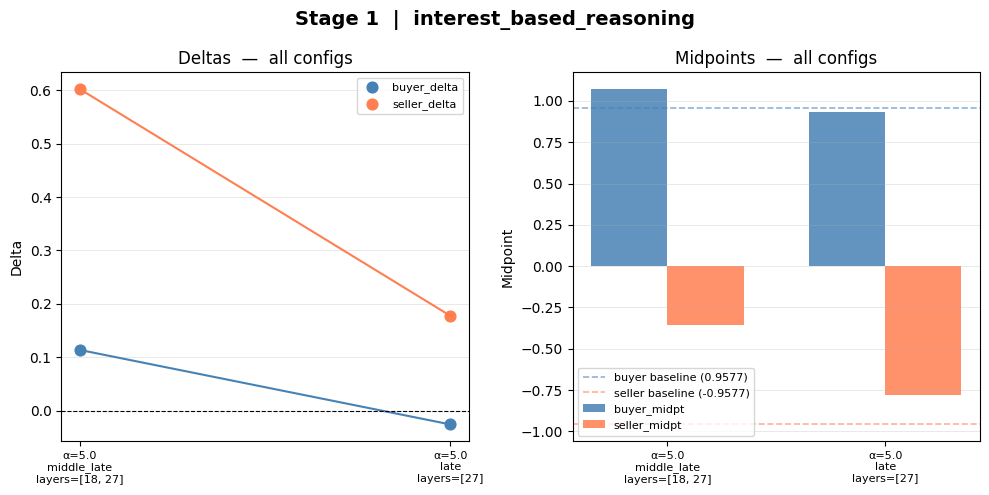


  STAGE 2  |  interest_based_reasoning  (11 configs)
Saved: gridsearch_neg15dim_12pairs_matched/interest_based_reasoning/stage2_plot.png


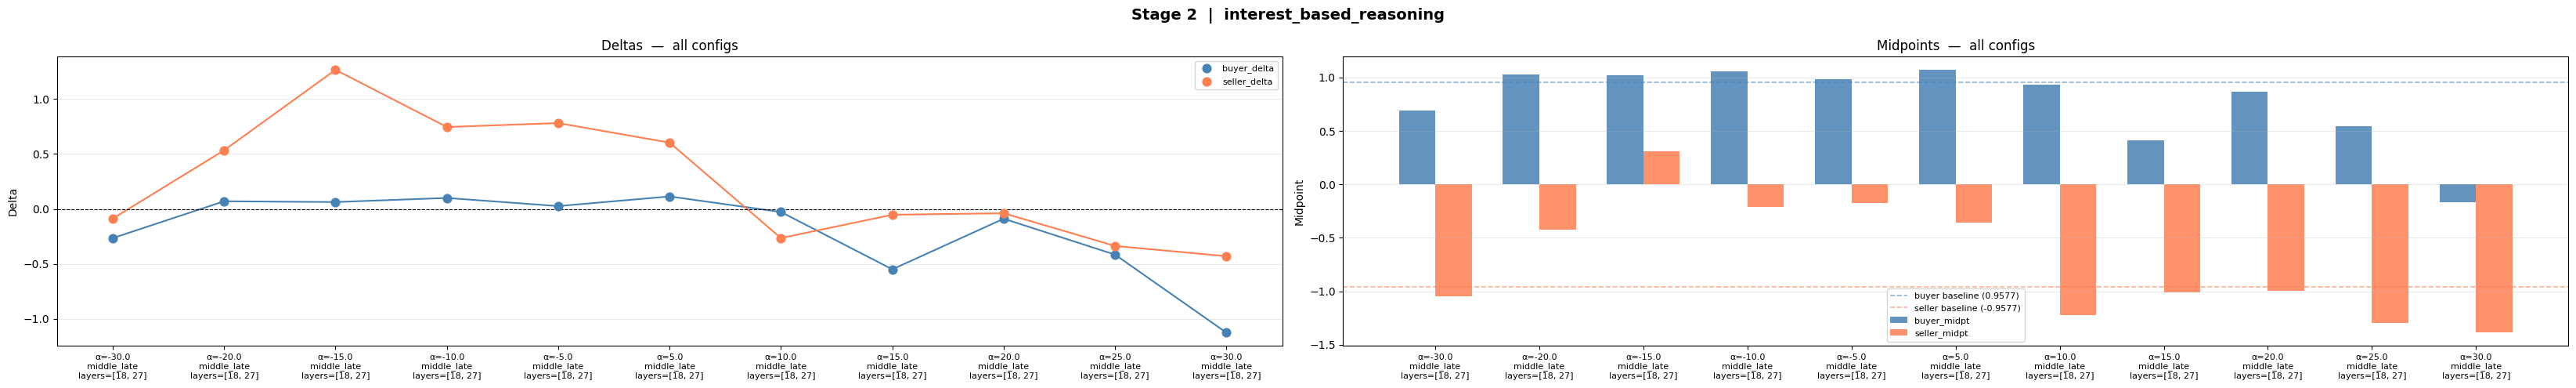

  STAGE 1  |  rapport_building  (2 configs)
Saved: gridsearch_neg15dim_12pairs_matched/rapport_building/stage1_plot.png


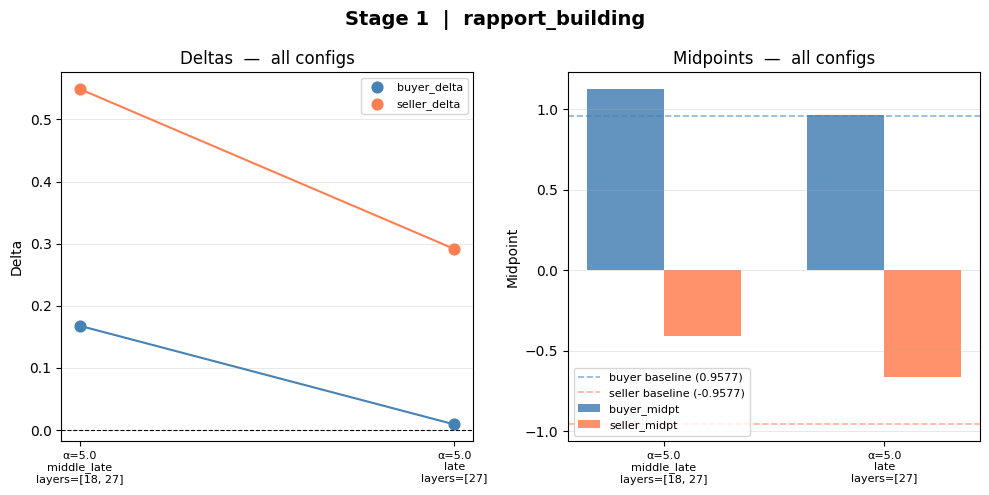


[!] No stage2_results.json found for 'rapport_building'
  STAGE 1  |  strategic_concession_making  (2 configs)
Saved: gridsearch_neg15dim_12pairs_matched/strategic_concession_making/stage1_plot.png


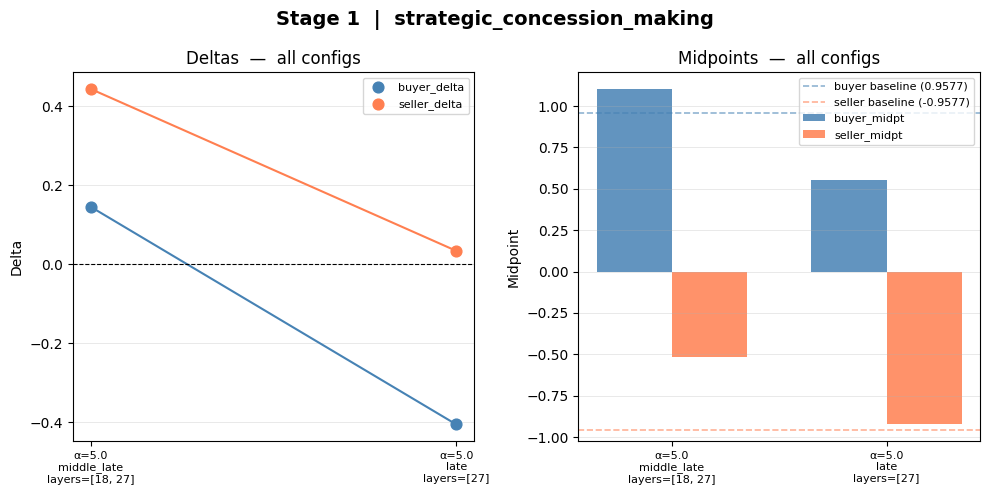


  STAGE 2  |  strategic_concession_making  (11 configs)
Saved: gridsearch_neg15dim_12pairs_matched/strategic_concession_making/stage2_plot.png


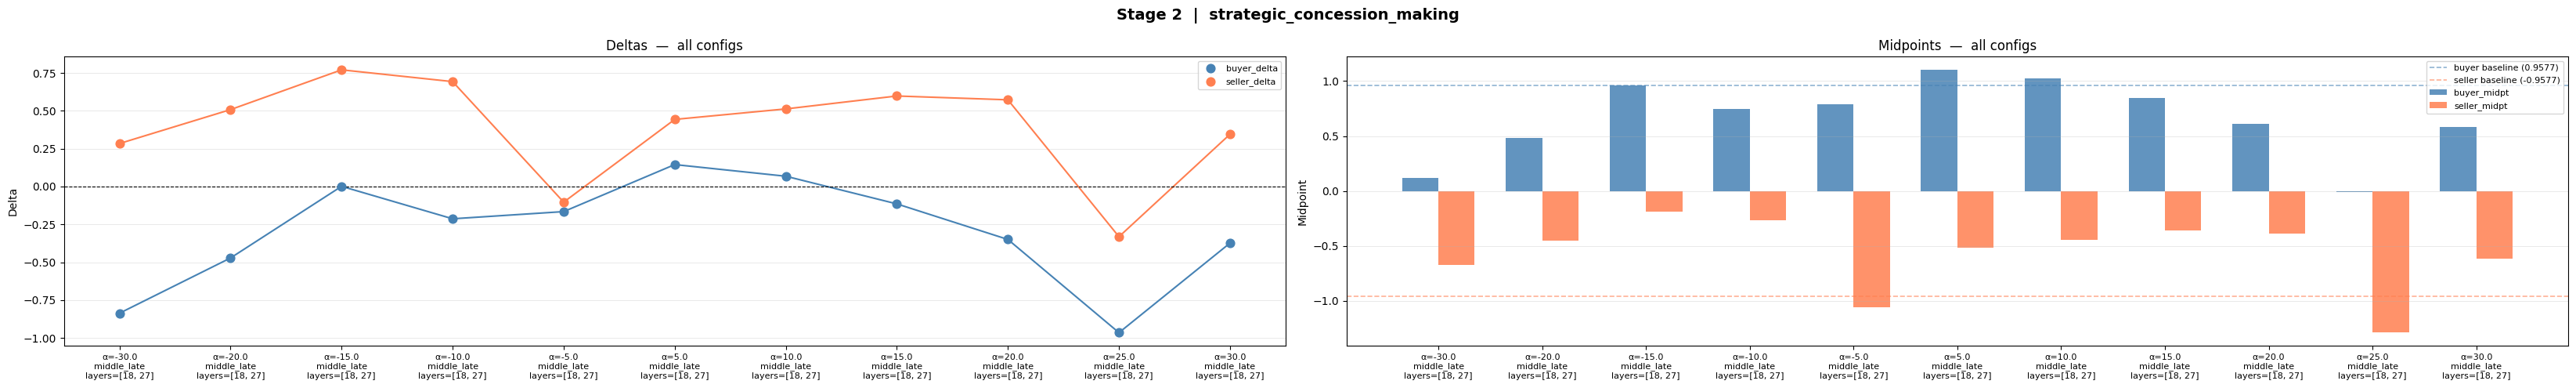

In [9]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict

BASE_PATH = Path("gridsearch_neg15dim_12pairs_matched")

DIMENSIONS = [
    "active_listening", "anchoring", "assertiveness",
    "emotional_regulation", "empathy", "firmness",
    "interest_based_reasoning", "rapport_building", "strategic_concession_making"
]


def _config_label(entry):
    layers = entry["layer_indices"]
    preset = entry["preset"]
    alpha = entry["alpha"]
    return f"α={alpha}\n{preset}\nlayers={layers}"


def _plot_two_graphs(ax_delta, ax_midpt, entries, x_labels, title_suffix, baseline_from=None):
    x = np.arange(len(entries))
    w = 0.35

    buyer_deltas  = [e["buyer_delta"]  for e in entries]
    seller_deltas = [e["seller_delta"] for e in entries]
    buyer_midpts  = [e["buyer_midpt"]  for e in entries]
    seller_midpts = [e["seller_midpt"] for e in entries]
    buyer_base    = (baseline_from or entries[0])["buyer_baseline_midpt"]
    seller_base   = (baseline_from or entries[0])["seller_baseline_midpt"]

    # --- delta graph: scatter + line ---
    ax_delta.plot(x, buyer_deltas,  color="steelblue", linewidth=1.5, linestyle="-")
    ax_delta.scatter(x, buyer_deltas,  color="steelblue", s=60, zorder=3, label="buyer_delta")
    ax_delta.plot(x, seller_deltas, color="coral",     linewidth=1.5, linestyle="-")
    ax_delta.scatter(x, seller_deltas, color="coral",     s=60, zorder=3, label="seller_delta")
    ax_delta.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax_delta.set_xticks(x)
    ax_delta.set_xticklabels(x_labels, fontsize=8)
    ax_delta.set_ylabel("Delta")
    ax_delta.set_title(f"Deltas  —  {title_suffix}")
    ax_delta.legend(fontsize=8)
    ax_delta.grid(axis="y", linewidth=0.4, alpha=0.5)

    # --- midpoint graph: bars ---
    ax_midpt.bar(x - w/2, buyer_midpts,  w, label="buyer_midpt",  color="steelblue", alpha=0.85)
    ax_midpt.bar(x + w/2, seller_midpts, w, label="seller_midpt", color="coral",     alpha=0.85)
    ax_midpt.axhline(buyer_base,  color="steelblue", linewidth=1.2, linestyle="--", alpha=0.6, label=f"buyer baseline ({buyer_base})")
    ax_midpt.axhline(seller_base, color="coral",     linewidth=1.2, linestyle="--", alpha=0.6, label=f"seller baseline ({seller_base})")
    ax_midpt.set_xticks(x)
    ax_midpt.set_xticklabels(x_labels, fontsize=8)
    ax_midpt.set_ylabel("Midpoint")
    ax_midpt.set_title(f"Midpoints  —  {title_suffix}")
    ax_midpt.legend(fontsize=8)
    ax_midpt.grid(axis="y", linewidth=0.4, alpha=0.5)


def plot_dimension(dimension):
    dim_path = BASE_PATH / dimension

    s1_path = dim_path / "stage1_results.json"
    s2_path = dim_path / "stage2_results.json"

    if not s1_path.exists():
        print(f"[!] No stage1_results.json found for '{dimension}'")
        return

    with open(s1_path) as f:
        stage1 = json.load(f)

    stage2 = None
    if s2_path.exists():
        with open(s2_path) as f:
            stage2 = json.load(f)

    # Sort by alpha ascending (-30 → 30)
    stage1 = sorted(stage1, key=lambda e: e["alpha"])

    # ------------------------------------------------------------------ #
    #  Stage 1
    # ------------------------------------------------------------------ #
    print(f"{'='*60}")
    print(f"  STAGE 1  |  {dimension}  ({len(stage1)} configs)")
    print(f"{'='*60}")

    s1_labels = [_config_label(e) for e in stage1]
    fig_w = max(10, len(stage1) * 3)
    fig, (ax_d, ax_m) = plt.subplots(1, 2, figsize=(fig_w, 5))
    fig.suptitle(f"Stage 1  |  {dimension}", fontsize=14, fontweight="bold")
    _plot_two_graphs(ax_d, ax_m, stage1, s1_labels, title_suffix="all configs")
    plt.tight_layout()
    save_path = dim_path / "stage1_plot.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()

    # ------------------------------------------------------------------ #
    #  Stage 2
    # ------------------------------------------------------------------ #
    if stage2 is None:
        print(f"\n[!] No stage2_results.json found for '{dimension}'")
        return

    stage2 = sorted(stage2, key=lambda e: e["alpha"])

    print(f"\n{'='*60}")
    print(f"  STAGE 2  |  {dimension}  ({len(stage2)} configs)")
    print(f"{'='*60}")

    s2_labels = [_config_label(e) for e in stage2]
    fig_w = max(10, len(stage2) * 3)
    fig, (ax_d, ax_m) = plt.subplots(1, 2, figsize=(fig_w, 5))
    fig.suptitle(f"Stage 2  |  {dimension}", fontsize=14, fontweight="bold")
    _plot_two_graphs(ax_d, ax_m, stage2, s2_labels, title_suffix="all configs")
    plt.tight_layout()
    save_path = dim_path / "stage2_plot.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()


for dim in DIMENSIONS:
    plot_dimension(dim)
